# Hyperparameter Sweep

The goal of this notebook is to identify the best hyperparameter configuration for our current training pipeline, which includes:

- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **AdamW** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **OneCycleLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))
- Class balancing via a generated samples (see [Class Balance Notebook](07_class_balance.ipynb))

We perform the hyperparameter sweep using the **wandb API**, employing the Bayesian optimization method as defined in this [Sweep Configuration](../sweep.yaml). The objective is to maximize `final_val_mAP`, computed at the end of each training run with a different configuration.

Due to the computational cost, the sweep is run for a single seed. The top three configurations are subsequently evaluated across multiple seeds for validation in the next notebook.


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [ ]:
EXPERIMENT_NAME = "08a_hyperparameter_sweep"
RANDOM_SEED = 66

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time
import yaml

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

Load the hyperparameter sweep config from yaml file.

In [ ]:
with open(PROJECT_PATH / "sweep.yaml", "r") as f:
    sweep_config = yaml.safe_load(f)
    
print("Configuration:")
print(sweep_config)

Configuration:
{'method': 'bayes', 'metric': {'name': 'final_val_mAP', 'goal': 'maximize'}, 'parameters': {'init_learning_rate': {'distribution': 'log_uniform_values', 'min': '1e-4', 'max': '1e-2'}, 'weight_decay': {'distribution': 'log_uniform_values', 'min': '1e-6', 'max': '1e-3'}, 'embedding_dim': {'values': [128, 256, 384, 512]}, 'hidden_dim': {'values': [256, 512, 768, 1024]}, 'dropout': {'values': [0.0, 0.1, 0.2, 0.3, 0.4]}, 'proxyanchor_margin': {'values': [0.05, 0.1, 0.15, 0.2, 0.3]}, 'proxyanchor_alpha': {'values': [16, 32, 48, 64]}, 'proxyanchor_lambda': {'distribution': 'log_uniform_values', 'min': '1e-5', 'max': '5e-2'}, 'batch_size': {'values': [32, 64, 128]}, 'eta_min': {'distribution': 'log_uniform_values', 'min': '1e-6', 'max': '1e-4'}, 'dinov3_model': {'value': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m'}, 'num_epochs': {'value': 200}, 'patience': {'value': 10}, 'val_split': {'value': 0.2}, 'seed': {'value': 66}, 'max_num_runs': {'value': 5}}}


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    sweep_id = wandb.sweep(
        sweep_config,
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Create sweep with ID: xnqw8dig
Sweep URL: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reidentification/sweeps/xnqw8dig


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


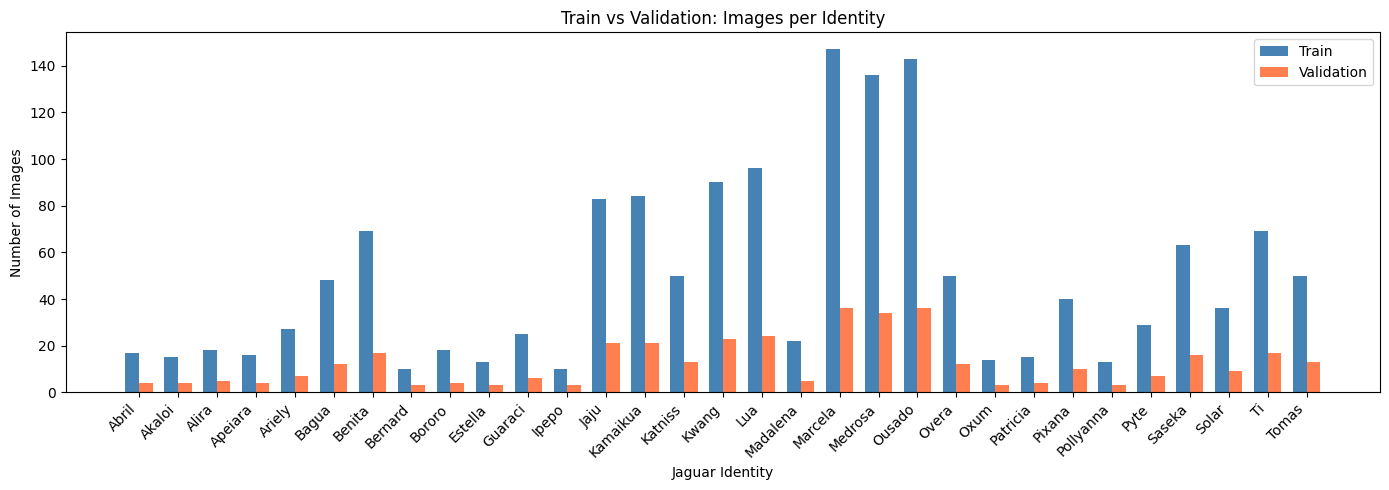


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=sweep_config["parameters"]["val_split"]["value"],
    random_state=sweep_config["parameters"]["seed"]["value"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-sweep_config['parameters']['val_split']['value']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*sweep_config['parameters']['val_split']['value']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
identity_information = {
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
}

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    sweep_config["parameters"]["dinov3_model"]["value"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


  Embedding dimension: 768


We use the augmentations from the previous notebook to generate additional samples for underrepresented identities.

In [ ]:
augment = transforms.Compose([
    # Randomly flip images horizontally; mimic different side of jaguar
    transforms.RandomHorizontalFlip(),

    # Crop and resize randomly to simulate different distances and framing
    transforms.RandomResizedCrop(dino_dim, scale=(0.85, 1.0)),

    # Small rotations to account for camera angle variation without distorting fur patterns
    transforms.RandomRotation(15),

    # Slight affine transformation: translation and scaling to simulate animal movement
    transforms.RandomAffine(
        degrees=0,           # no extra rotation
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Subtle color changes to mimic lighting variation; avoid distorting natural fur
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),

    # Apply slight blur to simulate motion blur or out-of-focus shots
    transforms.GaussianBlur(5, sigma=(0.1, 1.0)),
])

In [ ]:
augment_dir = OUTPUT_PATH / "augmented_data"
os.makedirs(augment_dir, exist_ok=True)

train_image_paths = np.array(image_paths)[train_mask]

augmented_paths = []
augmented_labels = []

for label in tqdm(range(num_classes), desc="Augmenting classes"):

    mask = train_labels == label
    label_paths = train_image_paths[mask]
    needed = max(0, sweep_config["parameters"]["min_images_per_identity"] - len(label_paths))

    print(f"Class {label}: {len(label_paths)} samples, need {needed} more")

    for i in range(needed):

        img_path = random.choice(label_paths)
        filename = img_path.stem
        
        # Use filename to hinder data leakage from previous runs on validation set
        save_path = augment_dir / f"class{label}_aug_{filename}.png"

        # To save computation, we only compute images once.
        if not save_path.exists():
            img = Image.open(img_path).convert("RGBA")

            aug_img = augment(img)
            aug_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)

augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)

combined_train_paths = np.concatenate([train_image_paths, augmented_paths])
combined_train_labels = np.concatenate([train_labels, augmented_labels])

combined_train_filenames = np.array([p.name for p in combined_train_paths])

In [ ]:
val_paths = np.array(image_paths)[~train_mask]
val_filenames = np.array([p.name for p in val_paths])

all_paths = np.concatenate([combined_train_paths, val_paths])
all_filenames = np.concatenate([combined_train_filenames, val_filenames])

image_dataset = BlurImageDataset(
    all_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

In [ ]:
baseline_cache_path = OUTPUT_PATH / "dino_blur_embeddings_augmented.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=all_filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


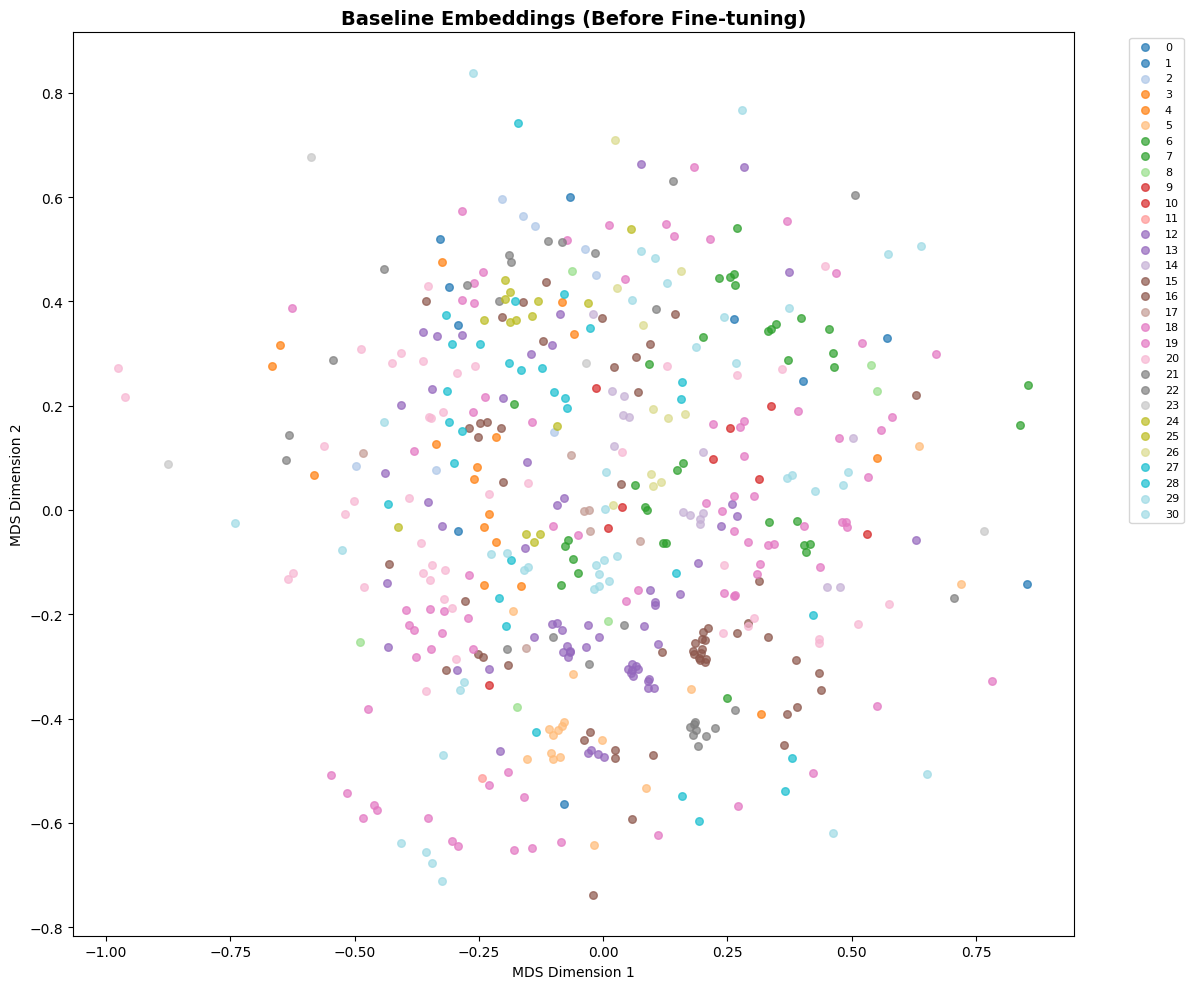

In [ ]:
# Visualize DINO embeddings
dino_embedding_fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=sweep_config["parameters"]["seed"]["value"]
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

In [ ]:
# Train Dataset contains real and augmented images
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[:len(combined_train_paths)],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[len(combined_train_paths):],
    val_labels
)

## Sweep

First, we create all training components based on the current run configuration.


In [ ]:
def create_training_components(config, device):
    model = EmbeddingProjection(
        input_dim=dino_dim,
        output_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"]
    ).to(device)
    
    wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})
    
    criterion = CombinedLoss(
        first_loss=CenterLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"]
        ),
        second_loss=ProxyAnchorLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"], 
            margin=config["proxyanchor_margin"], 
            alpha=config["proxyanchor_alpha"]
        ),
        lambda_center=config["proxyanchor_lambda"]
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=config["init_learning_rate"],
        weight_decay=config["weight_decay"]
    )
    
    train_loader = create_deterministic_training_dataloader(
        baseline_emb_train_dataset,
        batch_size=config["batch_size"],
        seed=config['seed'],
        num_workers=num_workers,
        
    )

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["max_learning_rate"],
        epochs=config["num_epochs"],
        steps_per_epoch=len(train_loader),
        pct_start=config["pct_start"],
        anneal_strategy='cos',
        cycle_momentum=False,
    )

    val_loader = DataLoader(
        baseline_emb_val_dataset,
        batch_size=config["batch_size"],
        num_workers=num_workers,
        shuffle=False
    )

    return model, criterion, optimizer, scheduler, train_loader, val_loader

Define the main training function for the sweep. Logging is reduced to save memory and time, omitting embedding visualizations and neighbor plots.


In [ ]:
def train():
    with wandb.init() as run:
        run_id = run.id
        config = wandb.config
        
        wandb.log({
            "identity_distribution_table": wandb.Table(dataframe=distribution_df),
            "num_identities": num_classes,
            "train_samples": len(train_data),
            "val_samples": len(val_data),
            "train_samples_per_identity": wandb.Histogram(train_counts.values),
            "val_samples_per_identity": wandb.Histogram(val_counts.values),
        })

        model, criterion, optimizer, scheduler, train_loader, val_loader = create_training_components(config, device)
        checkpoint_path = CHECKPOINT_PATH / f"run_{run_id}.pth"

        set_seeds(config['seed'], silent=True)
        
        start_time = time.time()
        history, best_map, best_epoch = train_loop(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            scheduler,
            device,
            name=f"run_{run_id}",
            checkpoint_path=checkpoint_path,
            num_epochs=config["num_epochs"],
            patience=config["patience"],
            classes=label_encoder.classes_.tolist(),
            silent=True
        )
        train_time = time.time() - start_time

        wandb.log({
            "final_val_mAP": best_map,
            "best_epoch": best_epoch,
            "total_epochs": len(history['train_loss']),
            "training_time": train_time,
        })
        
        fig = plot_history(history, best_epoch)
        plt.savefig(CHECKPOINT_PATH / f'training_curves_{run_id}.png', dpi=150, bbox_inches='tight')
        wandb.log({"training_curves": wandb.Image(fig)})

        run_id += 1

    return model, history

Start the sweep agent. Note that this process may take a significant amount of time.


wandb: Agent Starting Run: wfhpck5q with config:
wandb: 	batch_size: 32
wandb: 	dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
wandb: 	dropout: 0
wandb: 	embedding_dim: 256
wandb: 	eta_min: 3.1020691129474077e-06
wandb: 	hidden_dim: 256
wandb: 	init_learning_rate: 0.006629402146760959
wandb: 	max_num_runs: 5
wandb: 	num_epochs: 200
wandb: 	patience: 10
wandb: 	proxyanchor_alpha: 16
wandb: 	proxyanchor_lambda: 0.0007201709305939615
wandb: 	proxyanchor_margin: 0.15
wandb: 	seed: 66
wandb: 	val_split: 0.2
wandb: 	weight_decay: 1.0218168667981188e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


{'batch_size': 32, 'dinov3_model': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m', 'dropout': 0, 'embedding_dim': 256, 'eta_min': 3.1020691129474077e-06, 'hidden_dim': 256, 'init_learning_rate': 0.006629402146760959, 'max_num_runs': 5, 'num_epochs': 200, 'patience': 10, 'proxyanchor_alpha': 16, 'proxyanchor_lambda': 0.0007201709305939615, 'proxyanchor_margin': 0.15, 'seed': 66, 'val_split': 0.2, 'weight_decay': 1.0218168667981188e-06}
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 6.6072
  Val Loss:   4.8251
  Val mAP:    0.4176 | LR: 6.63e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 3.4689
  Val Loss:   1.6622
  Val mAP:    0.6946 | LR: 6.63e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 1.9480
  Val Loss:   1.4890
  Val mAP:    0.7801 | LR: 6.63e-03
  [New best model saved]

Epoch 4/200


...

  Train Loss: 2.9208
  Val Loss:   2.7181
  Val mAP:    0.8623 | LR: 9.35e-03
  No improvement. Patience: 7/10

Epoch 30/200


  Train Loss: 2.9062
  Val Loss:   2.6060
  Val mAP:    0.8666 | LR: 9.32e-03
  No improvement. Patience: 8/10

Epoch 31/200


  Train Loss: 2.8839
  Val Loss:   2.6195
  Val mAP:    0.8722 | LR: 9.28e-03
  No improvement. Patience: 9/10

Epoch 32/200


  Train Loss: 2.8691
  Val Loss:   2.6248
  Val mAP:    0.8694 | LR: 9.25e-03
  No improvement. Patience: 10/10

Early stopping triggered after 32 epochs

Training complete!
Best epoch: 22, Val mAP: 0.8787


best_epoch,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
final_val_mAP,▁
learning_rate,████████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▁▁
num_identities,▁
total_epochs,▁
train_loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_samples,▁
training_time,▁
val_loss,█▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


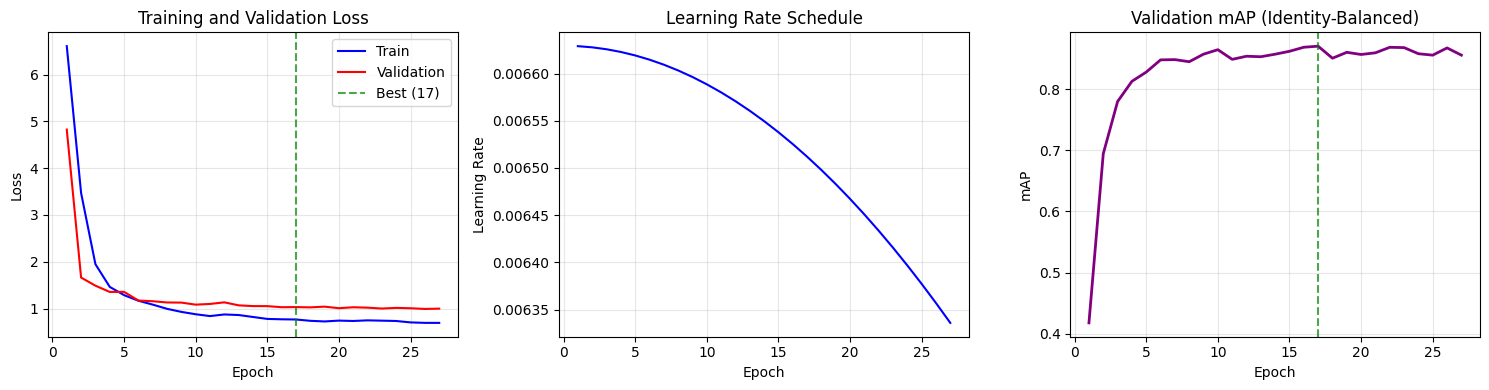

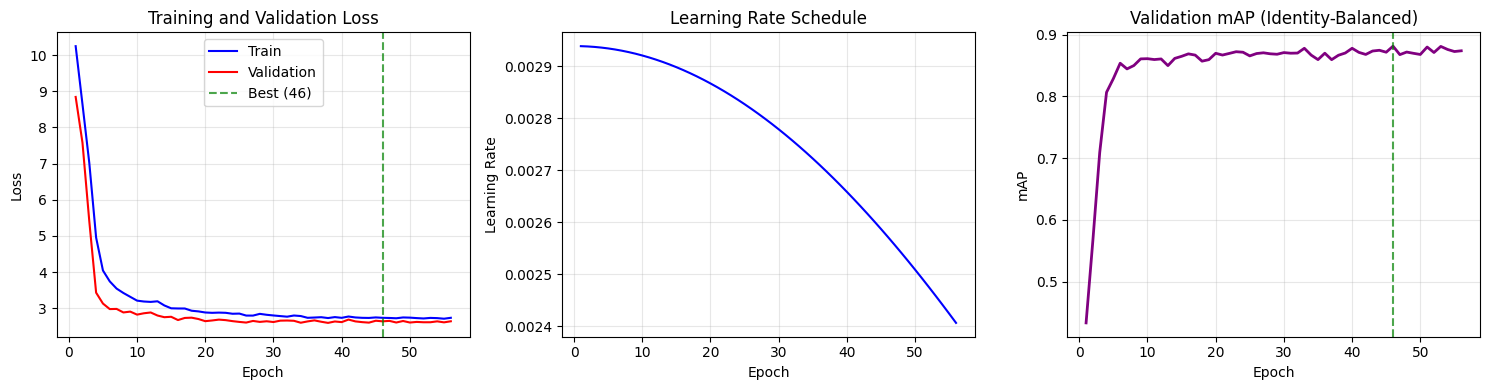

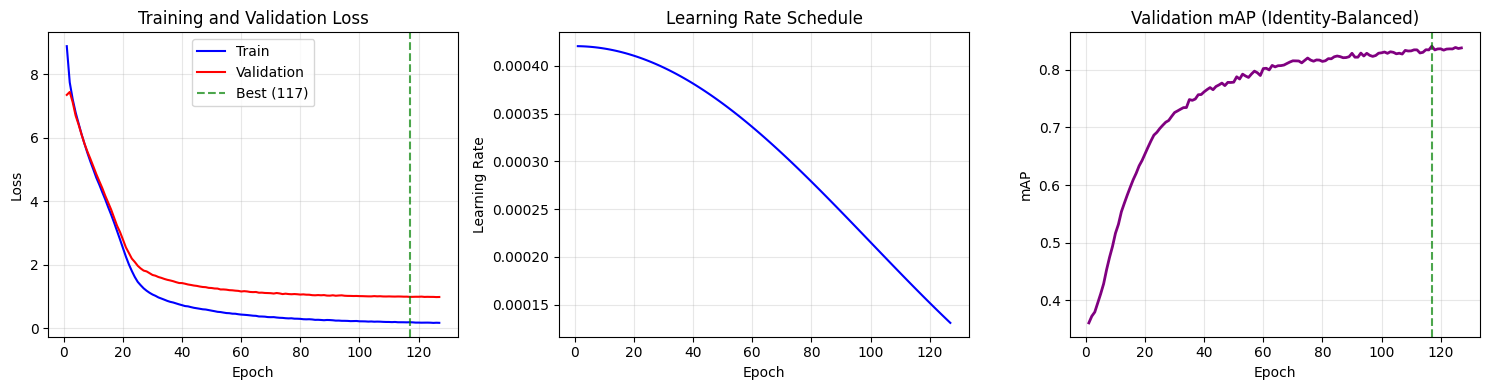

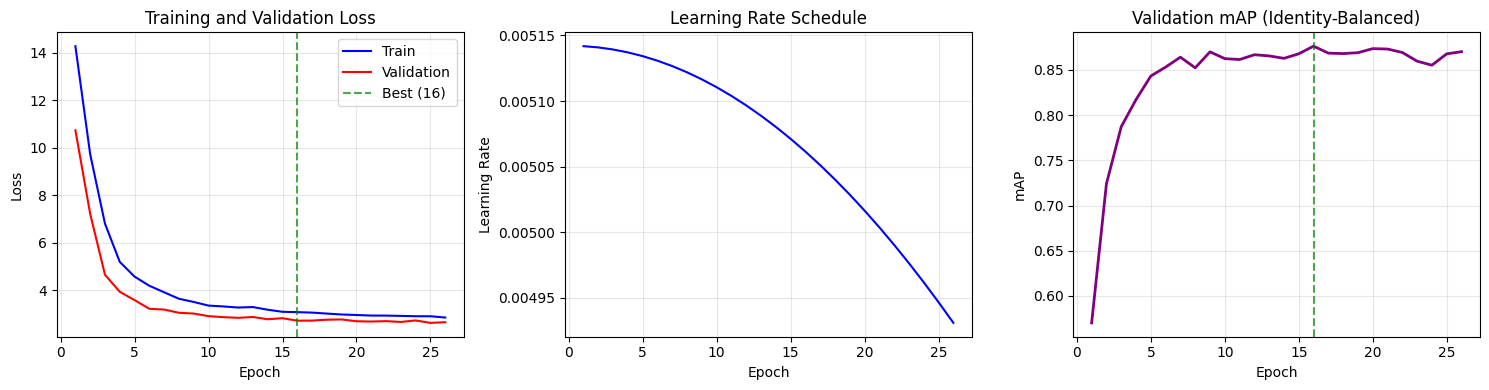

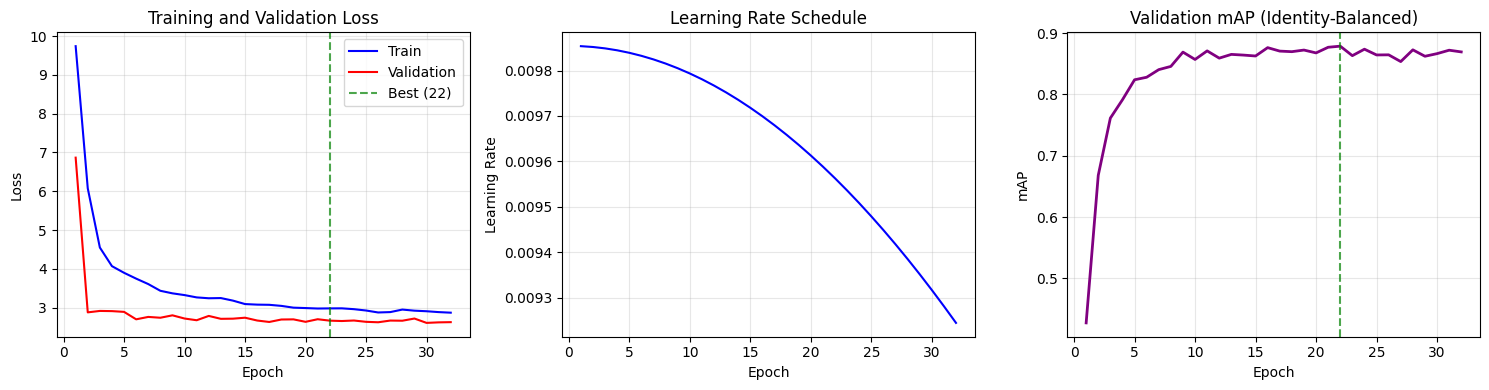

In [17]:
wandb.agent(
    sweep_id,
    function=train,
    count=sweep_config["parameters"]["max_num_runs"]["value"]
)

## Summary

In [26]:
api = wandb.Api()
entity = api.viewer.entity  # gets your W&B username
sweep_path = f"{entity}/{os.getenv('WANDB_PROJECT')}/{sweep_id}"
print(f"Sweep results available at: https://wandb.ai/{sweep_path}")

Sweep results available at: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reidentification/xnqw8dig


In [27]:
# Access the sweep via W&B API
api = wandb.Api()
sweep = api.sweep(sweep_path)

# Sort runs by your metric (final_val_mAP) descending
sorted_runs = sorted(
    sweep.runs, 
    key=lambda run: run.summary.get("final_val_mAP", float('-inf')),
    reverse=True
)

# Show the top 5 runs
print("Top 5 runs:")
for i, run in enumerate(sorted_runs[:5], 1):
    print(f"\nRank {i}:")
    print("Run ID:", run.id)
    print("final_val_mAP:", run.summary.get("final_val_mAP"))
    print("Hyperparameters:", run.config)

Top 5 runs:

Rank 1:
Run ID: vx5epydi
final_val_mAP: 0.8811980442213343
Hyperparameters: {'seed': 66, 'dropout': 0.1, 'eta_min': 2.0168036342892352e-06, 'patience': 10, 'val_split': 0.2, 'batch_size': 32, 'hidden_dim': 768, 'num_epochs': 200, 'dinov3_model': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m', 'max_num_runs': 5, 'weight_decay': 0.0002388749322419184, 'embedding_dim': 128, 'proxyanchor_alpha': 16, 'init_learning_rate': 0.0029385218190859375, 'proxyanchor_lambda': 0.001582464736144968, 'proxyanchor_margin': 0.3}

Rank 2:
Run ID: cj4rinhb
final_val_mAP: 0.8787463325670035
Hyperparameters: {'seed': 66, 'dropout': 0.2, 'eta_min': 7.721833800160476e-06, 'patience': 10, 'val_split': 0.2, 'batch_size': 32, 'hidden_dim': 512, 'num_epochs': 200, 'dinov3_model': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m', 'max_num_runs': 5, 'weight_decay': 0.0004200094897138458, 'embedding_dim': 128, 'proxyanchor_alpha': 16, 'init_learning_rate': 0.009854117580716488, 'proxyanchor_lambda': 2.50744

We will do a sensitity analysis in the following notebook.

## Submission

For submission we take the best run from hyperparameter sweep.

In [ ]:
best_run = sorted_runs[0]
best_run_id = best_run.id
best_run_config = best_run.config
print(f"\nBest run ID: {best_run_id}")

In [ ]:
model = EmbeddingProjection(
    input_dim=dino_dim,
    output_dim=best_run_config["embedding_dim"],
    hidden_dim=best_run_config["hidden_dim"],
    dropout=["dropout"]
).to(device)

checkpoint = torch.load(CHECKPOINT_PATH / f"run_{best_run_id}.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=32,
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")